In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
import nltk


In [4]:
df=pd.read_csv("Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df['Text'].values[1]

'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

In [6]:
df.shape

(568454, 10)

In [7]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

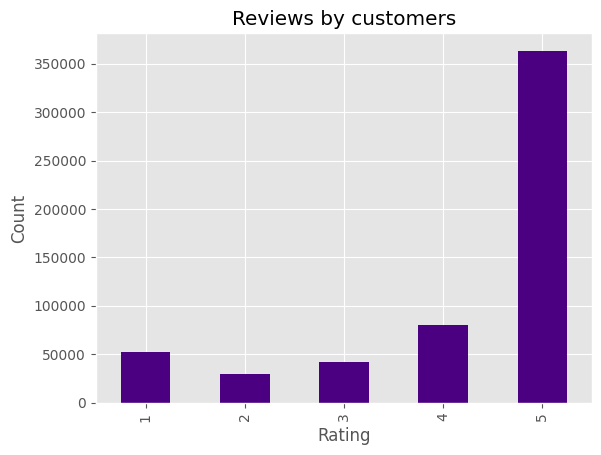

In [8]:
import matplotlib.pyplot as plt

ax = df['Score'].value_counts().sort_index().plot(
    kind='bar',
    title="Reviews by customers",
    color="indigo"
)

ax.set_xlabel("Rating")
ax.set_ylabel("Count")

plt.show()

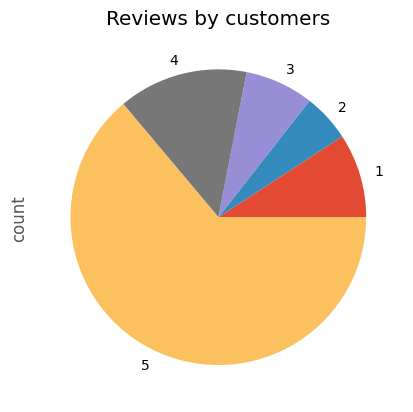

In [9]:
import matplotlib.pyplot as plt

ax = df['Score'].value_counts().sort_index().plot(
    kind='pie',
    title="Reviews by customers"
)

plt.show()

In [10]:
df['UserId'].value_counts()

UserId
A3OXHLG6DIBRW8    448
A1YUL9PCJR3JTY    421
AY12DBB0U420B     389
A281NPSIMI1C2R    365
A1Z54EM24Y40LL    256
                 ... 
AEW1UWTI3MCVN       1
ALMANY3CKWVH7       1
A1UJMVE0LCOI45      1
A6RFVZFCCPPAB       1
A24LQ099X444C1      1
Name: count, Length: 256059, dtype: int64

In [11]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [12]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from wordcloud import WordCloud

In [14]:
type(plt)

module

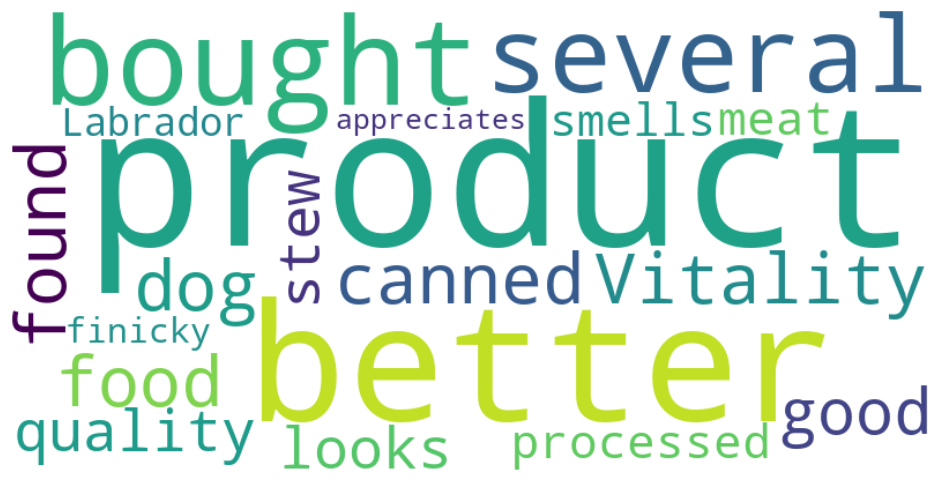

In [15]:
text = df['Text'][0]

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

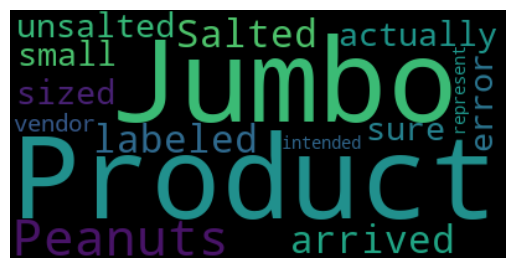

In [16]:
text = df.Text[1]

wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [17]:
# Randomly sample 10,000 reviews for analysis
df_sample = df.sample(n=10000, random_state=42).reset_index(drop=True)

In [18]:
sentence= df['Text'][1]
print(sentence)

Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".


In [19]:
tokens=nltk.word_tokenize(sentence)

#To view tokens
tokens

['Product',
 'arrived',
 'labeled',
 'as',
 'Jumbo',
 'Salted',
 'Peanuts',
 '...',
 'the',
 'peanuts',
 'were',
 'actually',
 'small',
 'sized',
 'unsalted',
 '.',
 'Not',
 'sure',
 'if',
 'this',
 'was',
 'an',
 'error',
 'or',
 'if',
 'the',
 'vendor',
 'intended',
 'to',
 'represent',
 'the',
 'product',
 'as',
 '``',
 'Jumbo',
 "''",
 '.']

In [20]:
from nltk.probability import FreqDist
freq_dist = FreqDist(tokens)
print(freq_dist)
freq_dist.most_common(3)

<FreqDist with 31 samples and 37 outcomes>


[('the', 3), ('as', 2), ('Jumbo', 2)]

In [21]:
from nltk.corpus import stopwords

stop_words=set(stopwords.words("english"))
print(stop_words)

{'hers', 'most', 'ma', 'such', 'then', 'there', 'their', 'here', 'can', 'the', 'herself', 're', 'down', 'my', 'you', 'didn', 'other', 'after', 'how', 'until', "isn't", 'd', 'so', "hasn't", 'any', 'm', 'only', 'more', "wasn't", 'do', "i'm", 'some', 'that', "he's", 'to', 'theirs', "doesn't", "it'd", 'him', 'were', 'when', 'because', 'our', 'shouldn', "she'll", "weren't", 'hasn', 'aren', 'now', 'just', 'hadn', 'being', 'll', 'mightn', 'this', 've', 'should', "shouldn't", 'a', 'has', "haven't", 'or', 'by', "mightn't", 'where', 'ourselves', 'myself', "should've", "we'd", "won't", "you've", 'will', 'does', 'own', 'couldn', 'below', "hadn't", 'them', "they're", 'yourselves', 'between', 'not', "i'd", 'be', 'nor', 'been', 'haven', 'ours', 'which', "it's", 'same', 'as', 'against', 'both', 'they', 'before', 'and', 'too', "couldn't", 'she', "we're", 'while', 'with', 'what', 'if', "you'll", 'but', 'is', 'wasn', 'i', 'won', 'from', "i'll", "needn't", 'once', 'have', "it'll", 'yours', "we'll", "she's

In [22]:
parts_of_speech=nltk.pos_tag(tokens)
parts_of_speech

[('Product', 'NNP'),
 ('arrived', 'VBD'),
 ('labeled', 'VBN'),
 ('as', 'IN'),
 ('Jumbo', 'NNP'),
 ('Salted', 'NNP'),
 ('Peanuts', 'NNP'),
 ('...', ':'),
 ('the', 'DT'),
 ('peanuts', 'NNS'),
 ('were', 'VBD'),
 ('actually', 'RB'),
 ('small', 'JJ'),
 ('sized', 'VBN'),
 ('unsalted', 'JJ'),
 ('.', '.'),
 ('Not', 'RB'),
 ('sure', 'JJ'),
 ('if', 'IN'),
 ('this', 'DT'),
 ('was', 'VBD'),
 ('an', 'DT'),
 ('error', 'NN'),
 ('or', 'CC'),
 ('if', 'IN'),
 ('the', 'DT'),
 ('vendor', 'NN'),
 ('intended', 'VBN'),
 ('to', 'TO'),
 ('represent', 'VB'),
 ('the', 'DT'),
 ('product', 'NN'),
 ('as', 'IN'),
 ('``', '``'),
 ('Jumbo', 'NNP'),
 ("''", "''"),
 ('.', '.')]

In [23]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
SIA=SentimentIntensityAnalyzer()

In [42]:
# create empty dictionary to store results
results = {}

for i, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    text = row['Text']
    myid = row['Id']
    results[myid] = SIA.polarity_scores(text)

Vaders = pd.DataFrame(results).T

Vaders = Vaders.reset_index().rename(columns={'index': 'Id'})

Vaders = Vaders.merge(df_sample, how='left')

Vaders

100%|██████████| 10000/10000 [00:12<00:00, 797.29it/s]


,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,165257,0.000,0.768,0.232,0.9684,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
1,231466,0.089,0.766,0.144,0.7920,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
2,427828,0.000,0.880,0.120,0.4588,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
3,433955,0.009,0.827,0.163,0.9923,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
4,70261,0.089,0.719,0.191,0.9421,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,477826,0.000,0.833,0.167,0.8625,B004UC0GIU,A17OE0VPF9FO97,Norman D. Lund,7,7,4,1325721600,"Frame is great, rest is flimsy - Thankfully th...","The frame of this is what holds the weight, an..."
9996,414356,0.000,0.879,0.121,0.9298,B001ELJK78,A1Y4DROW97OXL4,Toivo,2,2,4,1262649600,Pleasantly suprised,I ordered this kit just to try it since the pr...
9997,553965,0.000,0.789,0.211,0.8402,B001E5E0D8,A2XSQDY34DMXTA,"SMA ""SA""",0,0,5,1248739200,Super coffee,This espresso is amazing. My wife would not dr...
9998,471039,0.000,0.820,0.180,0.6901,B002HN2BM8,A2KGOD6XKLW2J8,"M. Morse ""Dita""",0,0,5,1311292800,Sweet!,I was so happy when I decided to look for Runt...


In [43]:
import sys
!{sys.executable} -m pip install transformers


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import sys
!{sys.executable} -m pip install scipy


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import torch
print(torch.__version__)

2.13.0+cpu


In [47]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

5.14.1
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\__init__.py


In [48]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

import os
print(os.path.dirname(transformers.__file__))

5.14.1
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\__init__.py
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers


In [49]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.__file__)

2.13.0+cpu
False
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\__init__.py


In [50]:
import transformers
from transformers.utils import is_torch_available

print(transformers.__version__)
print(is_torch_available())

5.14.1
True


In [34]:
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [51]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

5.14.1
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\__init__.py


In [52]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

print("Everything works!")

Everything works!


In [53]:
import transformers
import os

print(transformers.__file__)

print(os.listdir(os.path.dirname(transformers.__file__)))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\__init__.py
['activations.py', 'audio_utils.py', 'backbone_utils.py', 'cache_utils.py', 'cli', 'configuration_utils.py', 'conversion_mapping.py', 'convert_slow_tokenizer.py', 'convert_slow_tokenizers_checkpoints_to_fast.py', 'core_model_loading.py', 'data', 'debug_utils.py', 'dependency_versions_check.py', 'dependency_versions_table.py', 'distributed', 'dynamic_module_utils.py', 'exporters', 'feature_extraction_sequence_utils.py', 'feature_extraction_utils.py', 'file_utils.py', 'fusion_mapping.py', 'generation', 'hf_argparser.py', 'hyperparameter_search.py', 'image_processing_backends.py', 'image_processing_base.py', 'image_processing_outputs.py', 'image_processing_utils.py', 'image_transforms.py', 'image_utils.py', 'initialization.py', 'integrations', 'loss', 'masking_utils.py', 'modelcard.py', 'modeling_attn_mask_utils.py', 'modeling_flash_attention_utils.py', 'modeling_gguf_pytorch_utils.py', 'mod

In [54]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

print("Model loaded successfully!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 18212.86it/s]

Model loaded successfully!


In [55]:
from scipy.special import softmax

In [57]:
from torch.nn.functional import softmax
import torch
from tqdm import tqdm

def roberta_batch_scores(texts, batch_size=32):

    results = []

    for i in tqdm(range(0, len(texts), batch_size)):

        batch = texts[i:i+batch_size]

        encoded_text = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        with torch.no_grad():
            output = model(**encoded_text)

        scores = softmax(output.logits, dim=1)

        results.extend(scores.numpy())

    return results

In [58]:
texts = df_sample['Text'].tolist()

roberta_scores = roberta_batch_scores(texts)

100%|██████████| 313/313 [1:15:19<00:00, 14.44s/it]


In [59]:
roberta_df = pd.DataFrame(
    roberta_scores,
    columns=[
        'roberta_neg',
        'roberta_neu',
        'roberta_pos'
    ]
)

results_df = pd.concat(
    [df_sample.reset_index(drop=True), roberta_df],
    axis=1
)

In [60]:
results_df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,roberta_neg,roberta_neu,roberta_pos
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,0.004572,0.032567,0.962860
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...,0.003145,0.013015,0.983840
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...,0.501474,0.422844,0.075682
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin...",0.058795,0.318585,0.622620
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...,0.010467,0.048259,0.941274
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,477826,B004UC0GIU,A17OE0VPF9FO97,Norman D. Lund,7,7,4,1325721600,"Frame is great, rest is flimsy - Thankfully th...","The frame of this is what holds the weight, an...",0.006993,0.127046,0.865960
9996,414356,B001ELJK78,A1Y4DROW97OXL4,Toivo,2,2,4,1262649600,Pleasantly suprised,I ordered this kit just to try it since the pr...,0.011978,0.113637,0.874385
9997,553965,B001E5E0D8,A2XSQDY34DMXTA,"SMA ""SA""",0,0,5,1248739200,Super coffee,This espresso is amazing. My wife would not dr...,0.002310,0.019578,0.978112
9998,471039,B002HN2BM8,A2KGOD6XKLW2J8,"M. Morse ""Dita""",0,0,5,1311292800,Sweet!,I was so happy when I decided to look for Runt...,0.008121,0.027538,0.964340


In [61]:
results_df.shape
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      10000 non-null  int64  
 1   ProductId               10000 non-null  object 
 2   UserId                  10000 non-null  object 
 3   ProfileName             10000 non-null  object 
 4   HelpfulnessNumerator    10000 non-null  int64  
 5   HelpfulnessDenominator  10000 non-null  int64  
 6   Score                   10000 non-null  int64  
 7   Time                    10000 non-null  int64  
 8   Summary                 9999 non-null   object 
 9   Text                    10000 non-null  object 
 10  roberta_neg             10000 non-null  float32
 11  roberta_neu             10000 non-null  float32
 12  roberta_pos             10000 non-null  float32
dtypes: float32(3), int64(5), object(5)
memory usage: 898.6+ KB


In [62]:
results_df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   1
Text                      0
roberta_neg               0
roberta_neu               0
roberta_pos               0
dtype: int64

Rating Distribution

In [63]:
##Rating Distribution
results_df['Score'].value_counts().sort_index()

Score
1     891
2     507
3     750
4    1455
5    6397
Name: count, dtype: int64

In [65]:
from tqdm import tqdm

vader_results = {}

for i, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    text = row['Text']
    myid = row['Id']
    
    vader_results[myid] = SIA.polarity_scores(text)


vader_df = pd.DataFrame(vader_results).T

vader_df = vader_df.reset_index().rename(
    columns={'index':'Id'}
)

vader_df = vader_df.rename(columns={
    'neg':'vader_neg',
    'neu':'vader_neu',
    'pos':'vader_pos',
    'compound':'vader_compound'
})

100%|██████████| 10000/10000 [00:05<00:00, 1671.55it/s]


In [66]:
results_df = results_df.merge(
    vader_df,
    on='Id',
    how='left'
)

In [67]:
results_df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'vader_neg', 'vader_neu',
       'vader_pos', 'vader_compound'],
      dtype='object')

In [68]:
results_df['vader_sentiment'] = results_df['vader_compound'].apply(vader_sentiment)

In [69]:
##VADER Sentiment Distribution
def vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

results_df['vader_sentiment'] = results_df['vader_compound'].apply(vader_sentiment)

In [70]:
results_df['vader_sentiment'].value_counts()

vader_sentiment
Positive    8785
Negative    1001
Neutral      214
Name: count, dtype: int64

In [ ]:
##RoBERTa Sentiment Distribution

In [71]:
results_df['roberta_sentiment'] = (
    results_df[['roberta_neg','roberta_neu','roberta_pos']]
    .idxmax(axis=1)
)

In [72]:
results_df['roberta_sentiment'] = results_df['roberta_sentiment'].replace({
    'roberta_neg':'Negative',
    'roberta_neu':'Neutral',
    'roberta_pos':'Positive'
})

In [73]:
results_df['roberta_sentiment'].value_counts()

roberta_sentiment
Positive    7759
Negative    1496
Neutral      745
Name: count, dtype: int64

In [74]:
##Rating vs RoBERTa Sentiment
pd.crosstab(
    results_df['Score'],
    results_df['roberta_sentiment']
)

roberta_sentiment,Negative,Neutral,Positive
Score,,,
1,720,96,75
2,328,86,93
3,223,179,348
4,80,143,1232
5,145,241,6011


In [75]:
##VADER vs RoBERTa Comparison
pd.crosstab(
    results_df['vader_sentiment'],
    results_df['roberta_sentiment']
)

roberta_sentiment,Negative,Neutral,Positive
vader_sentiment,,,
Negative,680,106,215
Neutral,83,52,79
Positive,733,587,7465


In [76]:
##Review Length Analysis
results_df['review_length'] = results_df['Text'].apply(len)

In [77]:
#Average length by rating:
results_df.groupby('Score')['review_length'].mean()

Score
1    472.965208
2    473.388560
3    506.681333
4    481.274227
5    406.126466
Name: review_length, dtype: float64

In [78]:
#Average length by sentiment:
results_df.groupby('roberta_sentiment')['review_length'].mean()

roberta_sentiment
Negative    445.564840
Neutral     713.040268
Positive    404.935688
Name: review_length, dtype: float64

In [79]:
#Helpfulness Analysis
results_df['helpfulness_ratio'] = (
    results_df['HelpfulnessNumerator'] /
    results_df['HelpfulnessDenominator']
)

results_df['helpfulness_ratio'].fillna(0, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30548\2592860064.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  results_df['helpfulness_ratio'].fillna(0, inplace=True)


In [80]:
results_df.groupby('roberta_sentiment')['helpfulness_ratio'].mean()

roberta_sentiment
Negative    0.396547
Neutral     0.435488
Positive    0.410711
Name: helpfulness_ratio, dtype: float64

In [81]:
##Most Common Words in Negative Reviews
negative_reviews = results_df[
    results_df['roberta_sentiment']=='Negative'
]

In [82]:
##Misclassified / Interesting Reviews
#5-star but AI says negative
results_df[
    (results_df['Score']==5) &
    (results_df['roberta_sentiment']=='Negative')
][['Score','Text']]

,Score,Text
61,5,I almost do not want to purchase Green and Bla...
202,5,We just switched our English Bulldog from bull...
238,5,"My title says it all. Plus, the price per cup ..."
241,5,"I have small dogs (8 and 10 lbs), so these are..."
370,5,We have a new puppy who has to take antibiotic...
...,...,...
9431,5,We have this bread for breakfast every day and...
9492,5,You know how it is when your kitty literally g...
9549,5,Great for abrasions. Kept a slow healing/nonh...
9644,5,This is by far the best Crystal Light flavor e...


In [83]:
#1-star but AI says positive
results_df[
    (results_df['Score']==1) &
    (results_df['roberta_sentiment']=='Positive')
][['Score','Text']]

,Score,Text
30,1,I bought this item for my dog to play with. Sh...
262,1,"I've been giving my daughter Gerber fruits, ve..."
526,1,I LOVED this product...tasted wonderful. Much ...
655,1,We enjoy our soda stream alot.<br />But the sy...
720,1,"While this was brewing, I was excited. It sme..."
...,...,...
9394,1,"I have used this salt for years, but recently ..."
9461,1,You can order the same products online from Ne...
9605,1,I have recently fallen in love with Multi grai...
9783,1,If you buy these sauces directly from Ghirarde...


In [84]:
import os

os.makedirs("images", exist_ok=True)

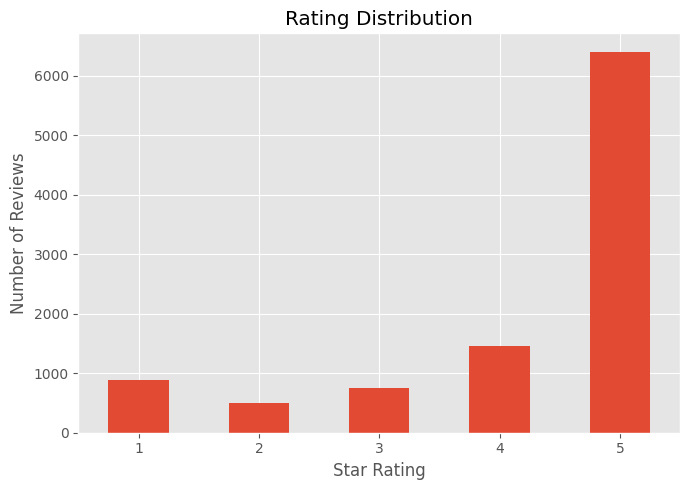

In [85]:
import matplotlib.pyplot as plt

rating_counts = results_df['Score'].value_counts().sort_index()

plt.figure(figsize=(7,5))
rating_counts.plot(kind='bar')

plt.title('Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('images/rating_distribution.png', dpi=300)

plt.show()

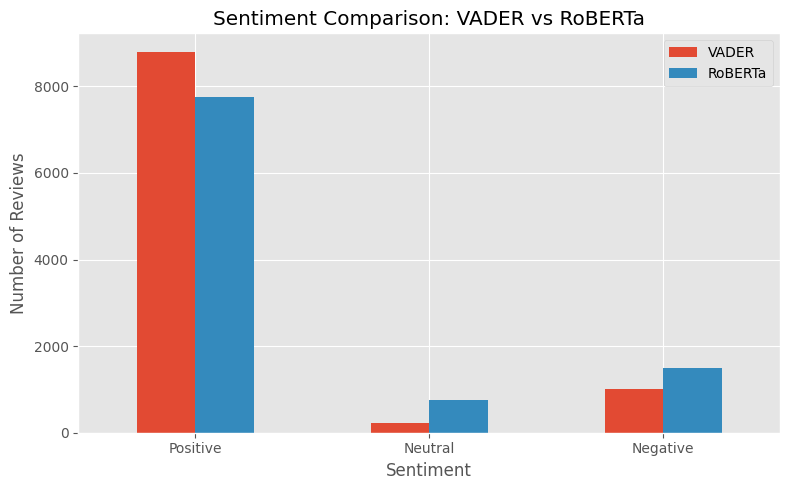

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'VADER': results_df['vader_sentiment'].value_counts(),
    'RoBERTa': results_df['roberta_sentiment'].value_counts()
}).fillna(0)

comparison = comparison.loc[['Positive','Neutral','Negative']]

comparison.plot(kind='bar', figsize=(8,5))

plt.title('Sentiment Comparison: VADER vs RoBERTa')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('images/sentiment_comparison.png', dpi=300)

plt.show()

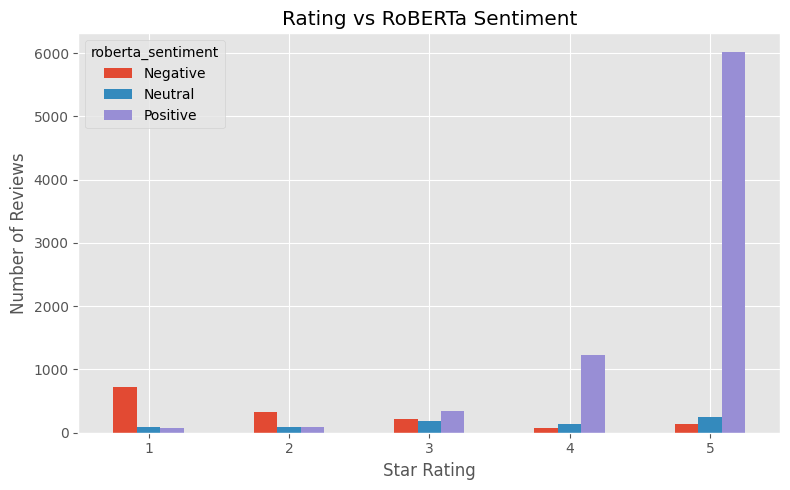

In [87]:
rating_sentiment = pd.crosstab(
    results_df['Score'],
    results_df['roberta_sentiment']
)

rating_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Rating vs RoBERTa Sentiment')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('images/rating_vs_sentiment.png', dpi=300)

plt.show()

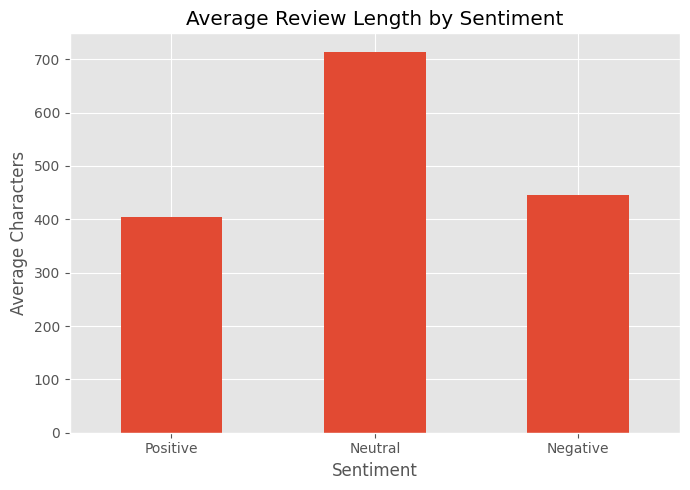

In [88]:
results_df['review_length'] = results_df['Text'].str.len()

review_length = results_df.groupby(
    'roberta_sentiment'
)['review_length'].mean()

review_length = review_length.loc[
    ['Positive','Neutral','Negative']
]

plt.figure(figsize=(7,5))

review_length.plot(kind='bar')

plt.title('Average Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Characters')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('images/review_length_analysis.png', dpi=300)

plt.show()

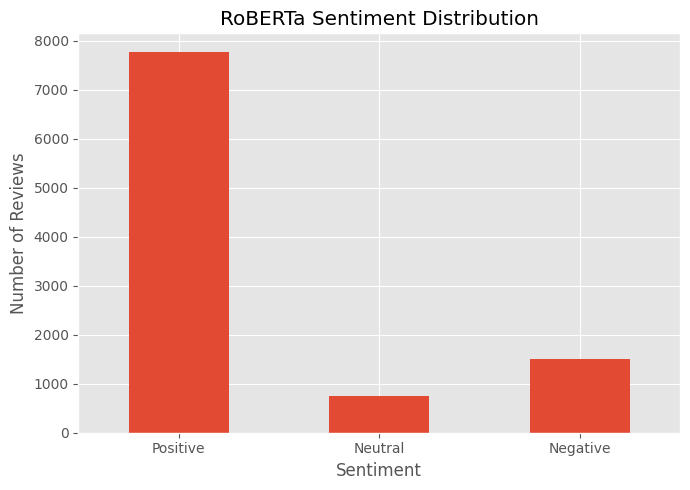

In [89]:
plt.figure(figsize=(7,5))

results_df['roberta_sentiment'].value_counts().loc[
    ['Positive','Neutral','Negative']
].plot(kind='bar')

plt.title('RoBERTa Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('images/roberta_sentiment_distribution.png', dpi=300)

plt.show()